In [3]:
%cd /home/govind/gov_semproject/GridCellsCopy

/home/govind/gov_semproject/GridCellsCopy


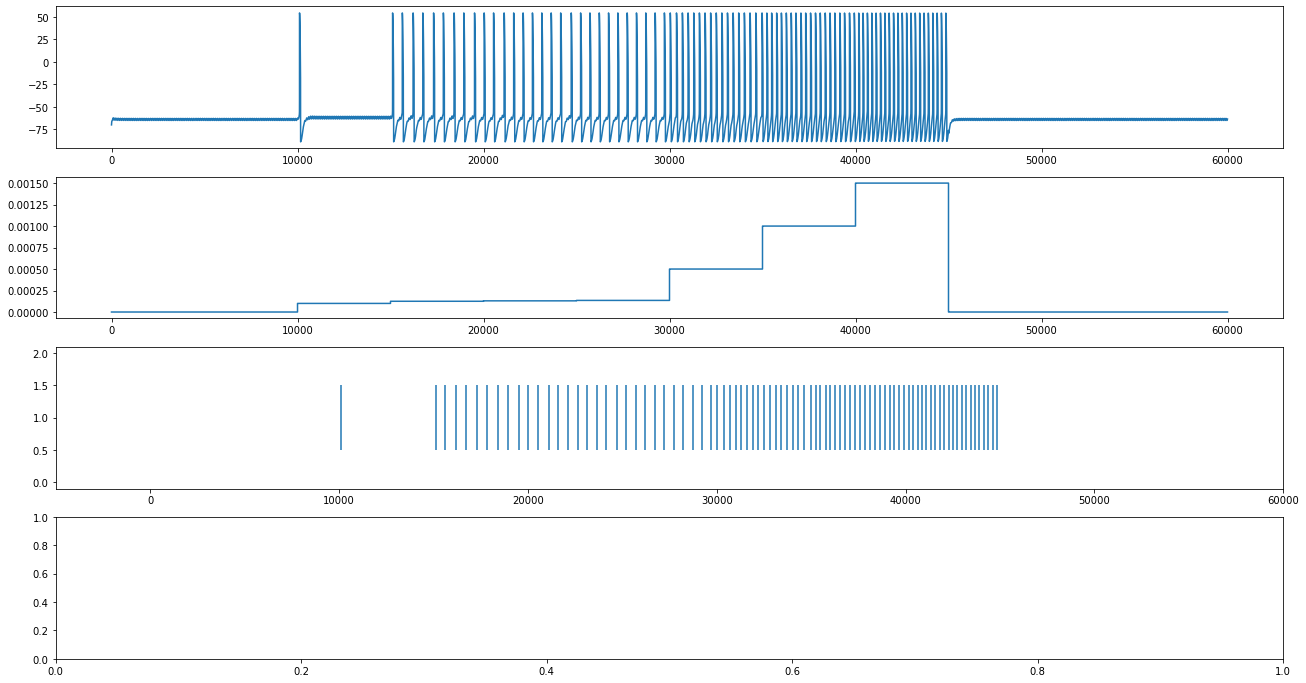

In [59]:
import interneuron
import analysis_utils as a_utils
import numpy as np
import matplotlib.pyplot as plt
from neuron import h
import importlib
importlib.reload(interneuron)

h.load_file("stdrun.hoc")
h.cvode_active(1)

test_interneuron = interneuron.Interneuron(0)

ic = h.IClamp(test_interneuron.soma(0.5))
ic.dur = 1e9
T, num_steps = 60,60000
time_arr = np.linspace(0,T,num_steps)

freq = 30
curr_amp = 1e-3
base_amp = 3e-3
baseline_arr = np.full_like(len(time_arr),base_amp)
amp_mod = np.abs(np.sin(2*np.pi*0.1*time_arr))
#curr_arr =  (curr_amp * np.abs(np.sin(2*np.pi*freq*time_arr))) + baseline_arr

curr_arr = np.zeros(len(time_arr))
curr_arr[10001:15000]=1.0e-4
curr_arr[15000:20000]=1.25e-4
curr_arr[20000:25000]=1.3e-4
curr_arr[25000:30000]=1.35e-4
curr_arr[30000:35000]=1.5e-4
curr_arr[30000:35000]=5e-4
curr_arr[35000:40000]=1e-3
curr_arr[40000:45000]=1.5e-3


curr_vec = h.Vector(curr_arr)

curr_vec.play(ic, ic._ref_amp, True)
rec_i = h.Vector().record(ic._ref_amp)
rec_v = h.Vector().record(test_interneuron.soma(0.5)._ref_v)
rec_t = h.Vector().record(h._ref_t)
spike_times = h.Vector()
nc = h.NetCon(test_interneuron.soma(0.5)._ref_v, None, sec=test_interneuron.soma)
nc.threshold=0
nc.record(spike_times)
#np_spike_times=np.array(spike_times)
h.finitialize(-70)
h.continuerun(60000)



fig,ax=plt.subplots(4,1,figsize=(22,12))
ax[0].plot(rec_t, rec_v)
ax[1].plot(rec_t, rec_i)
ax[2].eventplot(spike_times)
ax[2].set_xlim(-5000,60000)
plt.show()


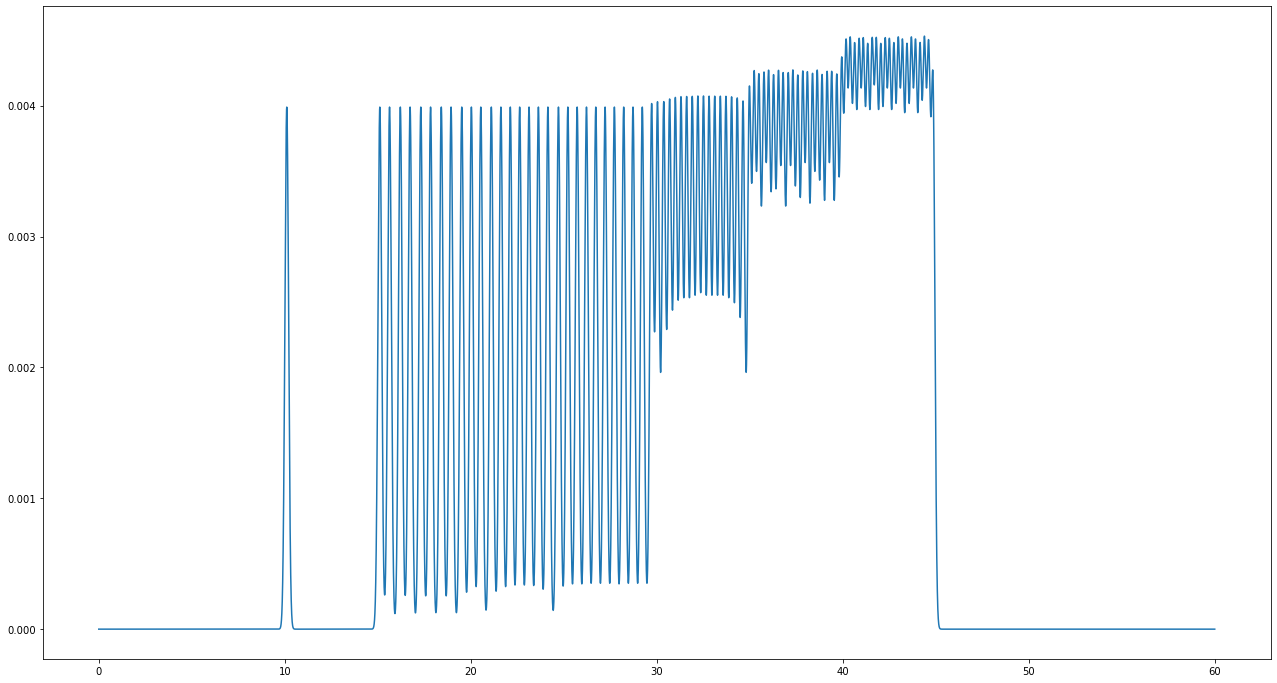

In [72]:
firing_rate = a_utils.instant_rate(spike_train=spike_times,stdev=100,sim_dur=60000)
plt.figure(figsize=(22,12))
plt.plot(time_arr,firing_rate)
plt.show()

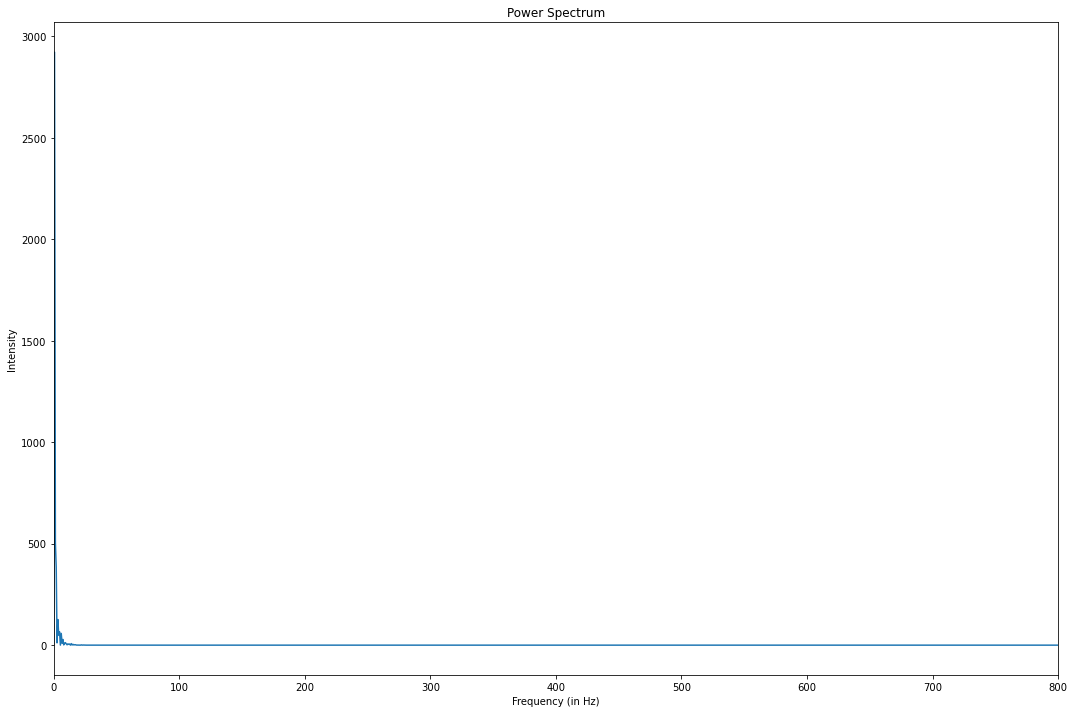

In [70]:
import g_utils
g_utils.plot_power_spectrum(firing_rate,xmax=800)

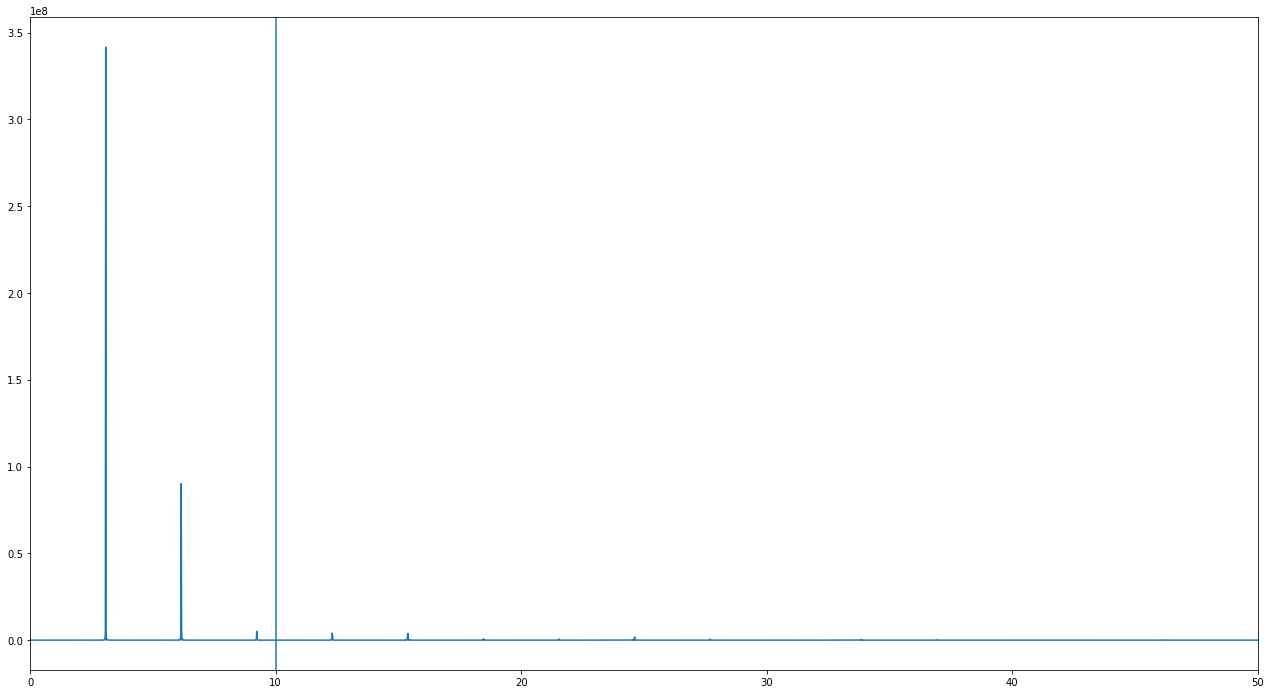

In [161]:
t_s = rec_t/1000
dt = t_s[1]-t_s[0]
fs=1/dt
v_centered = rec_v - np.mean(np.array(rec_v))
n=len(v_centered)
fft_vals = np.fft.rfft(v_centered)
fft_freqs = np.fft.rfftfreq(n,dt)
pow_spec = (np.abs(fft_vals)**2)/n
plt.figure(figsize=(22,12))
plt.plot(fft_freqs,pow_spec)
plt.axvline(x=10)
plt.xlim(0,50)
plt.show()